# Insurance Fraud Detection using Machine Learning

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("insurance_claims.csv")

We will first do the business understanding.

In [3]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [4]:
df.tail()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN
999,456,60,556080,1996-11-11,OH,250/500,1000,766.19,0,612260,...,?,5060,460,920,3680,Mercedes,E400,2007,N,NaN


In [5]:
df.shape

(1000, 40)

In [6]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

In [7]:
df.dtypes

months_as_customer               int64
age                              int64
policy_number                    int64
policy_bind_date                object
policy_state                    object
policy_csl                      object
policy_deductable                int64
policy_annual_premium          float64
umbrella_limit                   int64
insured_zip                      int64
insured_sex                     object
insured_education_level         object
insured_occupation              object
insured_hobbies                 object
insured_relationship            object
capital-gains                    int64
capital-loss                     int64
incident_date                   object
incident_type                   object
collision_type                  object
incident_severity               object
authorities_contacted           object
incident_state                  object
incident_city                   object
incident_location               object
incident_hour_of_the_day 

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [9]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


Data Cleaning

In [10]:
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

months_as_customer              391
age                              46
policy_number                  1000
policy_bind_date                951
policy_state                      3
policy_csl                        3
policy_deductable                 3
policy_annual_premium           991
umbrella_limit                   11
insured_zip                     995
insured_sex                       2
insured_education_level           7
insured_occupation               14
insured_hobbies                  20
insured_relationship              6
capital-gains                   338
capital-loss                    354
incident_date                    60
incident_type                     4
collision_type                    4
incident_severity                 4
authorities_contacted             4
incident_state                    7
incident_city                     7
incident_location              1000
incident_hour_of_the_day         24
number_of_vehicles_involved       4
property_damage             

In [13]:
df = df.drop(columns=["_c39"])

In [14]:
df.shape

(1000, 39)

In [15]:
df["collision_type"] = df["collision_type"].fillna("Not Applicable")

df["authorities_contacted"] = df["authorities_contacted"].fillna("None")

In [16]:
df["property_damage"] = df["property_damage"].replace("?", "Unknown")

df["police_report_available"] = df["police_report_available"].replace("?", "Unknown")

In [17]:
df["policy_bind_date"]=pd.to_datetime(df["policy_bind_date"])

df["incident_date"]=pd.to_datetime(df["incident_date"])

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

Exploratory Data Analysis

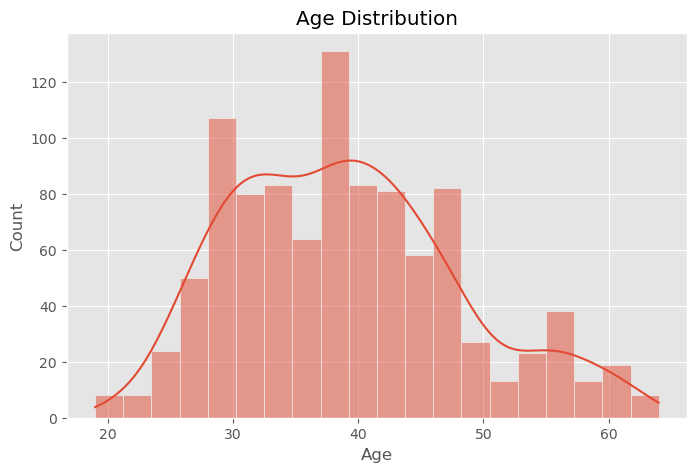

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

Most customers belong to the 30–45 years age group, indicating that middle-aged individuals form the major customer base.

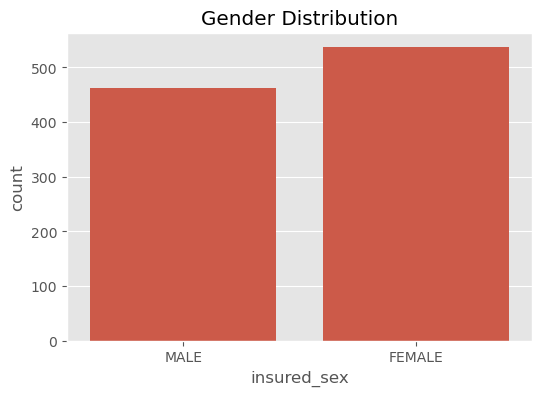

In [20]:
plt.figure(figsize=(6,4))

sns.countplot(x="insured_sex", data=df)

plt.title("Gender Distribution")

plt.show()

The dataset contains both male and female policyholders with a nearly balanced distribution.

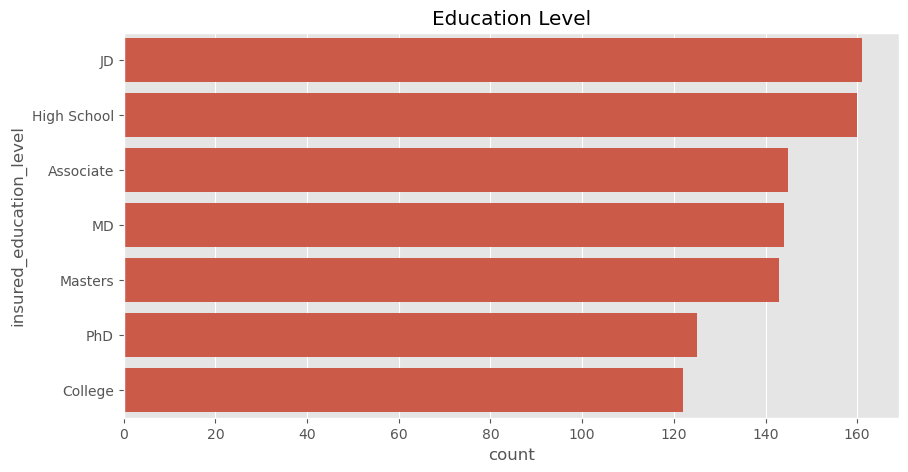

In [21]:
plt.figure(figsize=(10,5))

sns.countplot(
    y="insured_education_level",
    data=df,
    order=df["insured_education_level"].value_counts().index
)

plt.title("Education Level")

plt.show()

Customers come from diverse educational backgrounds, helping the insurer serve multiple customer segments.

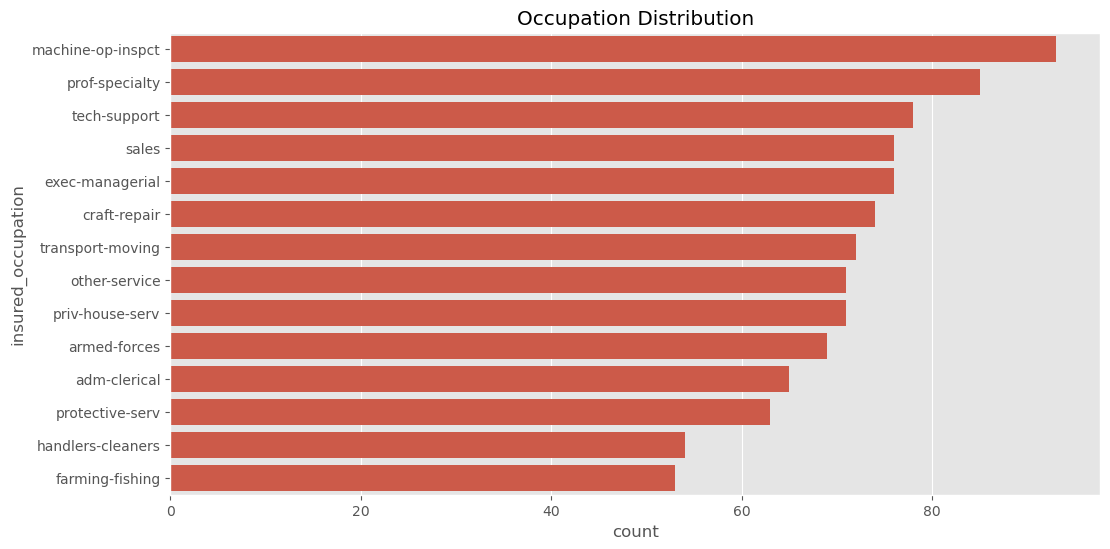

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="insured_occupation",
    data=df,
    order=df["insured_occupation"].value_counts().index
)

plt.title("Occupation Distribution")

plt.show()

The customer base includes multiple occupations, indicating that insurance policies are purchased across different professions.

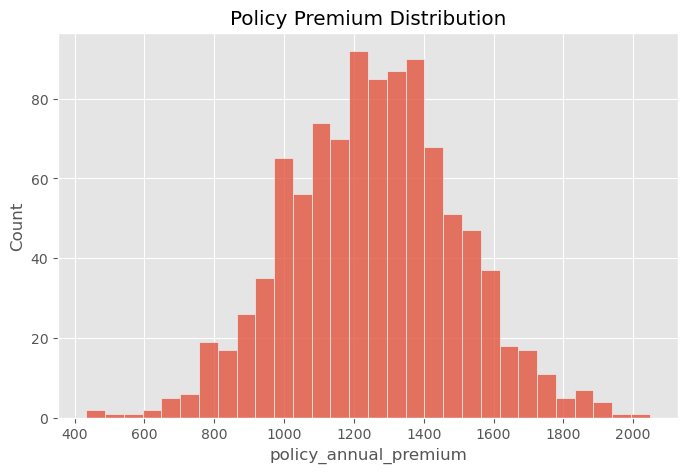

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df["policy_annual_premium"], bins=30)

plt.title("Policy Premium Distribution")

plt.show()

Most annual premiums are concentrated within a moderate range, with only a few very high premiums.
The company follows relatively standardized premium pricing while offering higher-value plans to a limited number of customers.

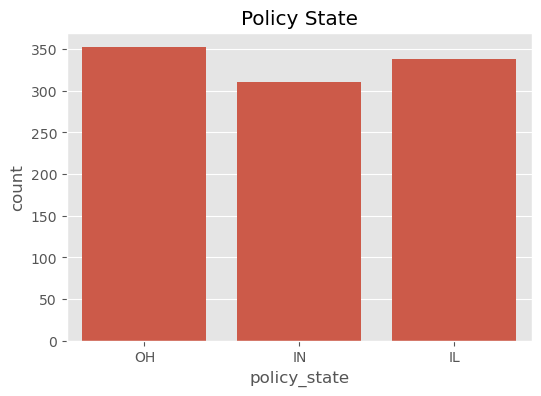

In [24]:
plt.figure(figsize=(6,4))

sns.countplot(x="policy_state", data=df)

plt.title("Policy State")

plt.show()

Policies are distributed across all available states, although some states have more policyholders than others.
States with higher policy counts contribute more to the company's customer base and may require greater operational support.

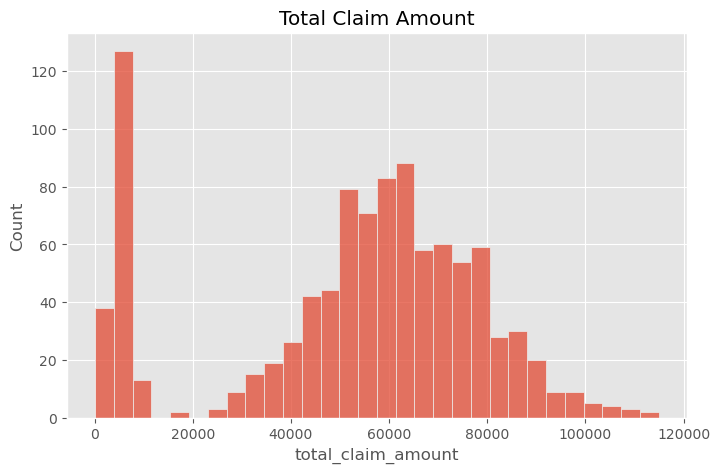

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["total_claim_amount"], bins=30)

plt.title("Total Claim Amount")

plt.show()

Most claim amounts fall within the medium range, while very high claims are comparatively rare.
The insurer mainly processes moderate-value claims, with only a few high-cost cases requiring special attention.

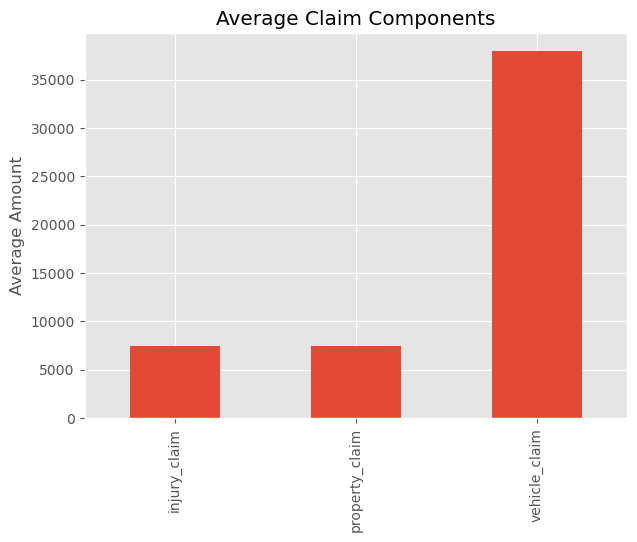

In [26]:
claims = df[["injury_claim",
             "property_claim",
             "vehicle_claim"]].mean()

claims.plot(kind="bar", figsize=(7,5))

plt.title("Average Claim Components")

plt.ylabel("Average Amount")

plt.show()

Vehicle claims contribute the highest average claim amount compared to injury and property claims.
Vehicle damage is the largest cost component, making it a key area for claim management and fraud monitoring.

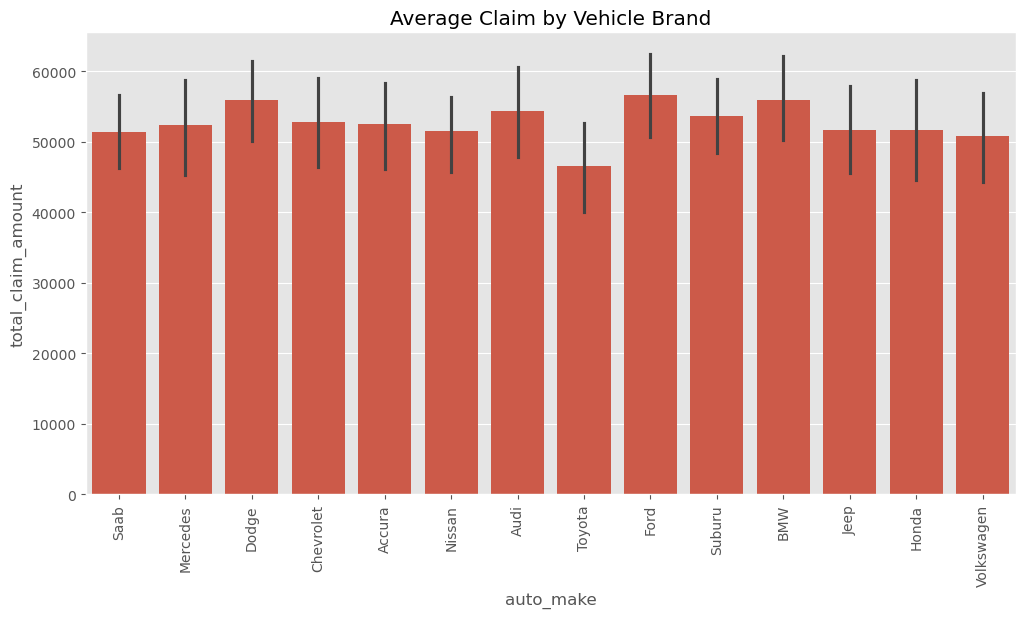

In [27]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="auto_make",
    y="total_claim_amount",
    data=df,
    estimator=np.mean
)

plt.xticks(rotation=90)

plt.title("Average Claim by Vehicle Brand")

plt.show()

Average claim amounts differ across vehicle manufacturers.
Certain vehicle brands are associated with higher claim costs, which can help in pricing and risk assessment.

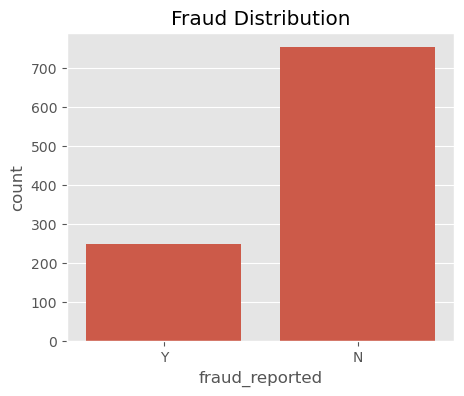

In [28]:
plt.figure(figsize=(5,4))

sns.countplot(x="fraud_reported", data=df)

plt.title("Fraud Distribution")

plt.show()

Most insurance claims are genuine, while a smaller percentage are reported as fraudulent.
The company should strengthen fraud detection processes while ensuring genuine customers experience minimal delays.

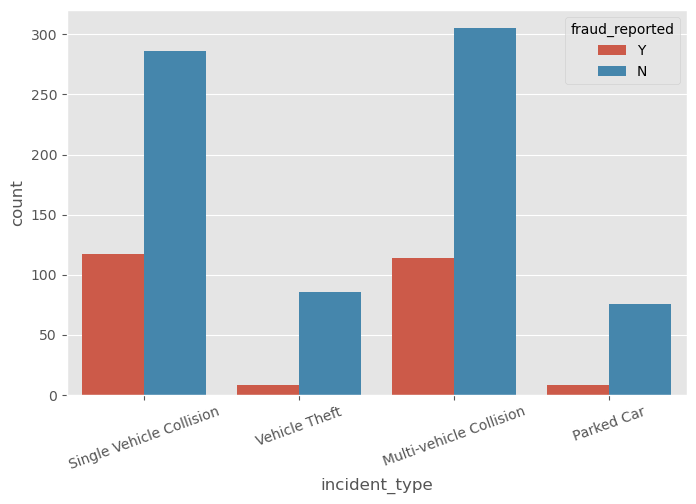

In [29]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="incident_type",
    hue="fraud_reported",
    data=df
)

plt.xticks(rotation=20)

plt.show()

Fraud frequency varies across different types of incidents.
Certain incident types may require additional verification because they show a higher likelihood of fraudulent claims.

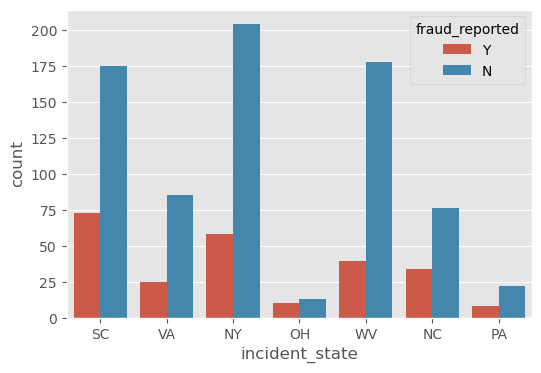

In [30]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="incident_state",
    hue="fraud_reported",
    data=df
)

plt.show()

The number of fraudulent claims differs from one state to another.
States with relatively higher fraud cases may benefit from stricter claim verification and monitoring.

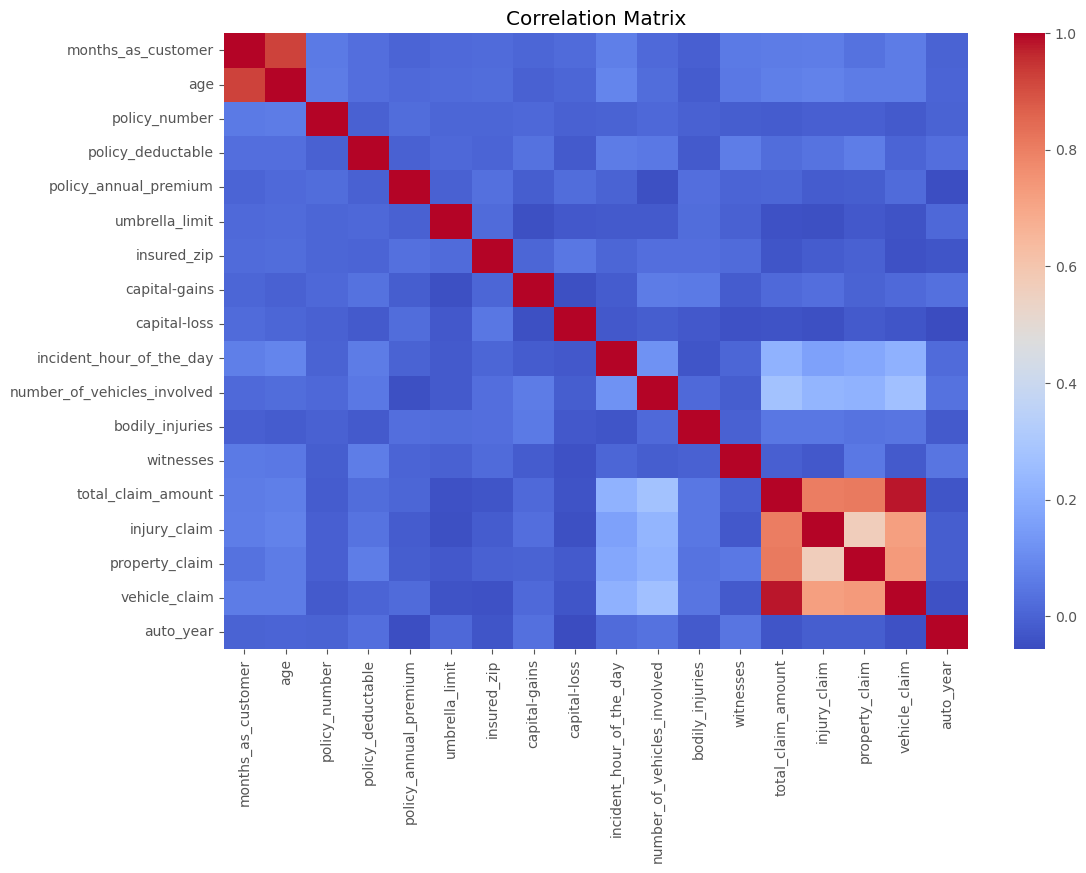

In [31]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

Some numerical variables show positive or negative relationships, while many have weak correlations.
Correlation analysis helps identify variables that may be useful for predictive modeling and feature selection.

Feature Engineering-
now we will be making new features.

In [32]:
df["customer_tenure_days"] = (
    df["incident_date"] - df["policy_bind_date"]
).dt.days

In [33]:
df["customer_tenure_days"].head()

0     100
1    3130
2    5282
3    8996
4     256
Name: customer_tenure_days, dtype: int64

In [34]:
df["customer_tenure_years"] = (
    df["customer_tenure_days"] / 365
).round(1)

In [35]:
df["customer_tenure_years"].head()

0     0.3
1     8.6
2    14.5
3    24.6
4     0.7
Name: customer_tenure_years, dtype: float64

In [36]:
df["claim_ratio"] = (
    df["total_claim_amount"] /
    df["policy_annual_premium"]
).round(2)

In [37]:
df["claim_ratio"].describe()

count    1000.000000
mean       43.770930
std        24.641952
min         0.070000
25%        32.357500
50%        44.975000
75%        58.690000
max       157.990000
Name: claim_ratio, dtype: float64

In [38]:
import os

download_path = os.path.join(os.path.expanduser("~"), "Downloads")

df.to_csv(
    os.path.join(download_path, "Insurance_Dashboard.csv"),
    index=False
)

print("Saved Successfully!")

Saved Successfully!


Data Preprocessing

In [39]:
df["fraud_reported"].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

In [40]:
df["fraud_reported"] = df["fraud_reported"].map({
    "N":0,
    "Y":1
})

In [41]:
df["fraud_reported"].value_counts()

fraud_reported
0    753
1    247
Name: count, dtype: int64

In [42]:
df.drop(columns=[
    "policy_number",
    "policy_bind_date",
    "incident_date",
    "incident_location",
    "insured_zip"
], inplace=True)

In [43]:
cat_cols = df.select_dtypes(include="object").columns

print(cat_cols)

Index(['policy_state', 'policy_csl', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'property_damage', 'police_report_available', 'auto_make',
       'auto_model'],
      dtype='object')


In [44]:
from sklearn.preprocessing import LabelEncoder

In [45]:
le = LabelEncoder()

In [46]:
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Creating Feature Matrix and Target Variable
The dataset is divided into independent variables (X) and the target variable (y). The model will use X to predict whether a claim is fraudulent or genuine.

In [47]:
X = df.drop("fraud_reported", axis=1)

In [48]:
y = df["fraud_reported"]

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [51]:
print(X_train.shape)
print(X_test.shape)

(800, 36)
(200, 36)


Model Building
The objective is to train different machine learning models and compare their performance for insurance fraud prediction.

Decision Tree
Decision Tree is a supervised machine learning algorithm that classifies data by creating decision rules based on feature values. 
It is capable of capturing non-linear relationships in the data.

In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
dt = DecisionTreeClassifier(random_state=42)

In [54]:
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [55]:
y_pred_dt = dt.predict(X_test)

Model Evaluation

In [56]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [57]:
dt_acc = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy :", dt_acc)

Decision Tree Accuracy : 0.775


Decision Tree Results

Accuracy: 77.5%
It was able to correctly identify 29 fraudulent claims while maintaining good performance on genuine claims.

Decision Tree performs better for fraud detection because it captures complex decision rules and identifies fraudulent claims.

In [58]:
print(confusion_matrix(y_test, y_pred_dt))

[[126  19]
 [ 26  29]]


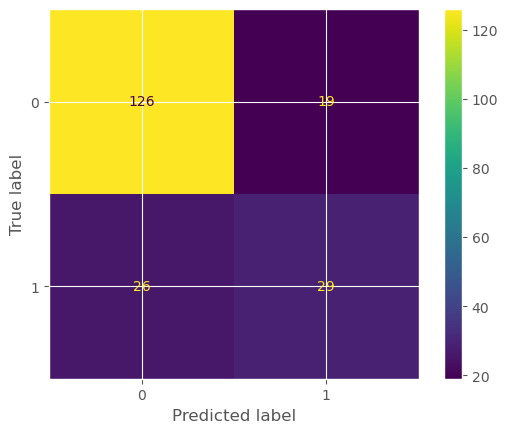

In [59]:
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)

plt.show()

In [60]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       145
           1       0.60      0.53      0.56        55

    accuracy                           0.78       200
   macro avg       0.72      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200



Model Performance Summary

The Decision Tree model achieved an accuracy of 77.5%.
The model correctly classified most genuine claims while also detecting fraudulent claims reasonably well.
Overall, the model provides a good balance between fraud detection and genuine claim classification.

Key Business Insights

1. Most policy holders belong to the age group of 30–45 years.
2. Vehicle claims contribute the highest proportion of total claim amounts.
3. Fraudulent claims are comparatively fewer than genuine claims.
4. Some incident types are associated with a higher proportion of fraud cases.
5. Decision Tree performed and was used for the fraud prediction.

Business Recommendations

1. Implement a fraud detection model before approving insurance claims.
2. Apply additional verification for claims with higher fraud risk.
3. Monitor high-value vehicle claims more closely.
4. Strengthen fraud investigation procedures for suspicious incidents.
5. Continuously update the prediction model using new claim data.

In [61]:
import os

download_path = os.path.join(os.path.expanduser("~"), "Downloads")

df.to_csv(
    os.path.join(download_path, "Insurance_Fraud_Final.csv"),
    index=False
)

print("File Saved Successfully!")

File Saved Successfully!
